<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Classification/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libraries

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing datasets

In [172]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
X = df.iloc[:, 2:-1].values
y = df.iloc[:, -1].values

##Taking care of missing data

###Find any missing values
both isna() and isnull() are the same thing

In [173]:
pd.isna(X).sum(), pd.isnull(y).sum()

(np.int64(0), np.int64(0))

### No missing values found, but if we get one then we can use these two
we have to go like this:

0th col then leave the 1st col(sex) then go for rest of the columns

In [174]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
imputer.fit(X[:, 0:1])
X[:, 0:1] = imputer.transform(X[:, 0:1])

In [175]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
imputer.fit(X[:, 2:])
X[:, 2:] = imputer.transform(X[:, 2:])

In [176]:
print(X)

##Encoding Categorical Values

In [177]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 1] = le.fit_transform(X[:, 1])
print(X)

##Splitting dataset into train and test split

In [178]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

##Feature Scaling

In [179]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Training the K-NN model on the training set

In [180]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

##Predicting the result

In [181]:
y_pred = classifier.predict(X_test)
y_pred_vector = y_pred.reshape(len(y_pred), 1)
y_test_vector = y_test.reshape(len(y_test), 1)

np.concatenate((y_pred_vector, y_test_vector), 1)

array([[0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0,

##Making confusion matrix

In [182]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[40  8]
 [ 3 29]]


###Visualize heatmap of confusion matrix

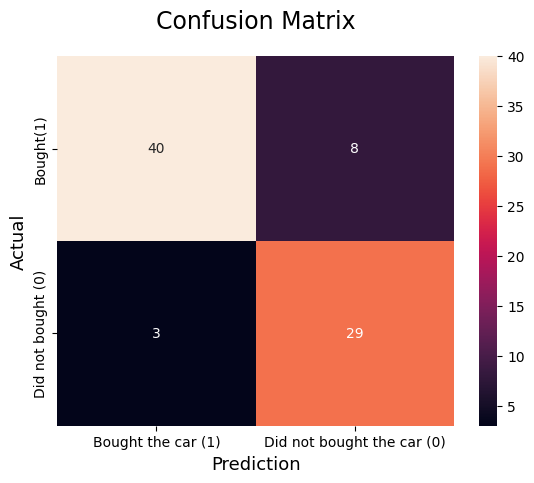

In [183]:
import seaborn as sns
sns.heatmap(cm, annot=True, xticklabels=['Bought the car (1)', 'Did not bought the car (0)'], yticklabels=['Bought(1)', 'Did not bought (0)'])

plt.title('Confusion Matrix', fontsize=17, pad=20)

plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)

plt.show()

## Printing accuracy score

In [184]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8625
